# 05 — Evaluation (your models)

Computes the **spec metrics** on the test set:
top-1 / top-5 accuracy, overall accuracy, macro precision / recall / F1,
confusion-matrix analysis, inference timing, and training curves if available.

**This notebook is for your runs** (from-scratch first).  
 trains pretrained get `best.pt`, you can point `OPTIONAL_SECOND_CKPT` at it for a side-by-side table. 


## 0. Colab bootstrap


In [1]:
# Colab bootstrap — mounts Drive, sets INAT_DATA_ROOT, installs deps.
# Safe no-op on local Cursor.

import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print(f"IN_COLAB = {IN_COLAB}")

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    DRIVE_SUBSET = Path("/content/drive/MyDrive/comp9517/subset")
    REPO_DIR = Path("/content/Haramcomp9517")
    BRANCH = "nate/pretrained-gradcam"
    REPO_URL = "https://github.com/NateRebello/Haramcomp9517.git"

    assert DRIVE_SUBSET.is_dir(), f"Missing {DRIVE_SUBSET} — check Drive path / shortcut"
    for split in ("train", "val", "test"):
        assert (DRIVE_SUBSET / split).is_dir(), f"Missing {DRIVE_SUBSET / split}"

    if not REPO_DIR.is_dir():
        # Fall back to main/deepl branch if Nate's branch is not on remote yet
        try:
            subprocess.check_call(
                ["git", "clone", "-b", BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)]
            )
        except subprocess.CalledProcessError:
            print(f"Branch {BRANCH} not on remote — cloning default branch")
            subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    else:
        subprocess.check_call(["git", "fetch", "origin"], cwd=REPO_DIR)

    pipeline = REPO_DIR / "dl_pipeline"
    # Prefer the uploaded notebook's sibling tree if present; else cloned repo
    os.chdir(pipeline)
    os.environ["INAT_DATA_ROOT"] = str(DRIVE_SUBSET)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"]
    )
    if str(pipeline) not in sys.path:
        sys.path.insert(0, str(pipeline))
    print("cwd =", os.getcwd())
    print("INAT_DATA_ROOT =", os.environ["INAT_DATA_ROOT"])
else:
    # Local: default DATA_ROOT is repo-root/subset via src.config
    print("Local run — using default DATA_ROOT unless INAT_DATA_ROOT is set.")

# Local Abdoali path lock (before src.config import)
import os
os.environ.setdefault(
    "INAT_DATA_ROOT",
    r"C:\Users\Abdoali\Comp9517\Group_project\inat_subset\subset",
)
print("INAT_DATA_ROOT =", os.environ["INAT_DATA_ROOT"])


IN_COLAB = False
Local run — using default DATA_ROOT unless INAT_DATA_ROOT is set.
INAT_DATA_ROOT = C:\Users\Abdoali\Comp9517\Group_project\inat_subset\subset


## 1. Setup

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

PIPELINE_ROOT = Path.cwd().resolve()
if PIPELINE_ROOT.name == "notebooks":
    PIPELINE_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from src.config import (
    BATCH_SIZE,
    CHECKPOINTS_DIR,
    NUM_CLASSES,
    RESULTS_DIR,
    SEED,
    ensure_output_dirs,
    set_seed,
)
from src.dataset import build_dataloaders, build_datasets, idx_to_category_id
from src.metrics import (
    collect_predictions,
    compute_metrics,
    make_confusion_matrix,
    most_confused_pairs,
)
from src.models import build_model
from src.train_utils import load_checkpoint

set_seed(SEED)
ensure_output_dirs()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}")

c:\Users\Abdoali\Comp9517\Group_project\dl_pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device=cuda


## 2. Checkpoint paths



In [3]:
SCRATCH_CKPT = CHECKPOINTS_DIR / "resnet18_scratch" / "best.pt"
SCRATCH_HISTORY = RESULTS_DIR / "resnet18_scratch_history.json"

PRETRAINED_CKPT = CHECKPOINTS_DIR / "resnet18_pretrained" / "best.pt"
PRETRAINED_HISTORY = RESULTS_DIR / "resnet18_pretrained_history.json"

# If Colab wiped local checkpoints, fall back to Drive copies
if not PRETRAINED_CKPT.is_file():
    drive_pt = Path("/content/drive/MyDrive/comp9517/checkpoints/resnet18_pretrained/best.pt")
    if drive_pt.is_file():
        PRETRAINED_CKPT = drive_pt
        print("Using Drive pretrained ckpt:", PRETRAINED_CKPT)

EVAL_BATCH = BATCH_SIZE
USE_AMP = True

print("scratch ckpt exists   :", SCRATCH_CKPT.is_file(), "→", SCRATCH_CKPT)
print("pretrained ckpt exists:", PRETRAINED_CKPT.is_file(), "→", PRETRAINED_CKPT)


scratch ckpt exists   : False → C:\Users\Abdoali\Comp9517\Group_project\Haramcomp9517\dl_pipeline\checkpoints\resnet18_scratch\best.pt
pretrained ckpt exists: True → C:\Users\Abdoali\Comp9517\Group_project\Haramcomp9517\dl_pipeline\checkpoints\resnet18_pretrained\best.pt


## 3. Data (test set only for final numbers)

In [4]:
train_ds, val_ds, test_ds = build_datasets(augment_train=False)
_, _, test_loader = build_dataloaders(
    train_ds, val_ds, test_ds, batch_size=EVAL_BATCH
)
cat_id = idx_to_category_id(train_ds)
labels = list(range(NUM_CLASSES))
print(f"test images={len(test_ds)}  classes={NUM_CLASSES}")

test images=5000  classes=500


## 4. Load model(s) and run test predictions

In [5]:
def load_resnet18_for_eval(ckpt_path: Path, *, pretrained_flag: bool) -> tuple:
    """Rebuild ResNet-18 and load weights. pretrained_flag is metadata only (weights come from ckpt)."""
    model = build_model("resnet18", num_classes=NUM_CLASSES, pretrained=False)
    ckpt = load_checkpoint(ckpt_path, model, map_location=device)
    model.to(device)
    model.eval()
    meta = {
        "epoch": ckpt.get("epoch"),
        "best_val_acc": ckpt.get("best_val_acc"),
        "config": ckpt.get("config", {}),
        "pretrained_flag": pretrained_flag,
    }
    return model, meta


def eval_one(name: str, ckpt_path: Path, *, pretrained_flag: bool) -> dict:
    print(f"\n=== Evaluating: {name} ===")
    model, meta = load_resnet18_for_eval(ckpt_path, pretrained_flag=pretrained_flag)
    print(f"ckpt epoch={meta['epoch']}  stored best_val_acc={meta['best_val_acc']}")

    preds = collect_predictions(model, test_loader, device, use_amp=USE_AMP, topk=5)
    metrics = compute_metrics(
        preds["y_true"], preds["y_pred"], preds["y_topk"], labels=labels
    )
    metrics["inference_logits_seconds"] = preds["logits_time"]
    metrics["inference_wall_seconds"] = preds["wall_time"]
    metrics["inference_img_per_sec"] = preds["n_samples"] / max(preds["logits_time"], 1e-8)
    metrics["n_test"] = preds["n_samples"]

    cm = make_confusion_matrix(preds["y_true"], preds["y_pred"], labels=labels)
    confused = most_confused_pairs(cm, cat_id, top_n=15)

    # Persist one JSON per model for the report table
    out_json = RESULTS_DIR / f"{name}_metrics.json"
    serialisable = {
        "name": name,
        "checkpoint": str(ckpt_path),
        "meta": {
            "epoch": meta["epoch"],
            "best_val_acc": meta["best_val_acc"],
            "config": meta.get("config", {}),
            "pretrained_flag": pretrained_flag,
        },
        "metrics": metrics,
        "most_confused_pairs": [
            {"true": a, "pred": b, "count": c} for a, b, c in confused
        ],
    }
    with out_json.open("w", encoding="utf-8") as f:
        json.dump(serialisable, f, indent=2)
    print(f"saved {out_json}")

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "name": name,
        "meta": meta,
        "metrics": metrics,
        "cm": cm,
        "confused": confused,
        "y_true": preds["y_true"],
        "y_pred": preds["y_pred"],
    }


results = []
to_eval = []
if SCRATCH_CKPT.is_file():
    to_eval.append(("resnet18_scratch", SCRATCH_CKPT, False))
else:
    print(f"Skipping scratch — missing {SCRATCH_CKPT}")

if PRETRAINED_CKPT.is_file():
    to_eval.append(("resnet18_pretrained", PRETRAINED_CKPT, True))
else:
    print(f"Skipping pretrained — missing {PRETRAINED_CKPT}")

assert to_eval, "No checkpoints found. Finish notebook 03 and/or 04 first."

for name, path, pre in to_eval:
    results.append(eval_one(name, path, pretrained_flag=pre))


Skipping scratch — missing C:\Users\Abdoali\Comp9517\Group_project\Haramcomp9517\dl_pipeline\checkpoints\resnet18_scratch\best.pt

=== Evaluating: resnet18_pretrained ===
ckpt epoch=9  stored best_val_acc=0.6226038338658147


saved C:\Users\Abdoali\Comp9517\Group_project\Haramcomp9517\dl_pipeline\results\resnet18_pretrained_metrics.json


## 5. Metrics table (report-ready)

In [6]:
rows = []
for r in results:
    m = r["metrics"]
    rows.append(
        {
            "model": r["name"],
            "top1_%": m["top1_acc"] * 100,
            "top5_%": m["top5_acc"] * 100,
            "macro_P": m["macro_precision"],
            "macro_R": m["macro_recall"],
            "macro_F1": m["macro_f1"],
            "infer_img/s": m["inference_img_per_sec"],
            "infer_s": m["inference_logits_seconds"],
        }
    )

metrics_df = pd.DataFrame(rows).round(4)
display(metrics_df)

out_csv = RESULTS_DIR / "test_metrics.csv"
metrics_df.to_csv(out_csv, index=False)
print(f"saved {out_csv}")

,model,top1_%,top5_%,macro_P,macro_R,macro_F1,infer_img/s,infer_s
0,resnet18_pretrained,61.02,81.94,0.6502,0.6102,0.609,695.3668,7.1904


saved C:\Users\Abdoali\Comp9517\Group_project\Haramcomp9517\dl_pipeline\results\test_metrics.csv


## 6. Training curves (scratch)

Loaded from the JSON written by notebook 03.

In [7]:
if SCRATCH_HISTORY.is_file():
    with SCRATCH_HISTORY.open() as f:
        payload = json.load(f)
    hist = payload["history"]
    epochs = range(1, len(hist["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, hist["train_loss"], label="train")
    axes[0].plot(epochs, hist["val_loss"], label="val")
    axes[0].set_title("Scratch — loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, [a * 100 for a in hist["train_acc"]], label="train")
    axes[1].plot(epochs, [a * 100 for a in hist["val_acc"]], label="val")
    axes[1].set_title("Scratch — top-1 acc (%)")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    cfg = payload.get("config", {})
    if "total_train_seconds" in cfg:
        print(f"total train time: {cfg['total_train_seconds']/60:.1f} min")
else:
    print(f"No history JSON at {SCRATCH_HISTORY} (finish notebook 03 full run).")

No history JSON at C:\Users\Abdoali\Comp9517\Group_project\Haramcomp9517\dl_pipeline\results\resnet18_scratch_history.json (finish notebook 03 full run).


## 7. Confusion matrix (subset view)

Full 500×500 is unreadable as a heatmap. We plot:
1. A **20-class slice** (first 20 indices) for a visual check
2. The **top confused category-id pairs** (table) for the report error analysis

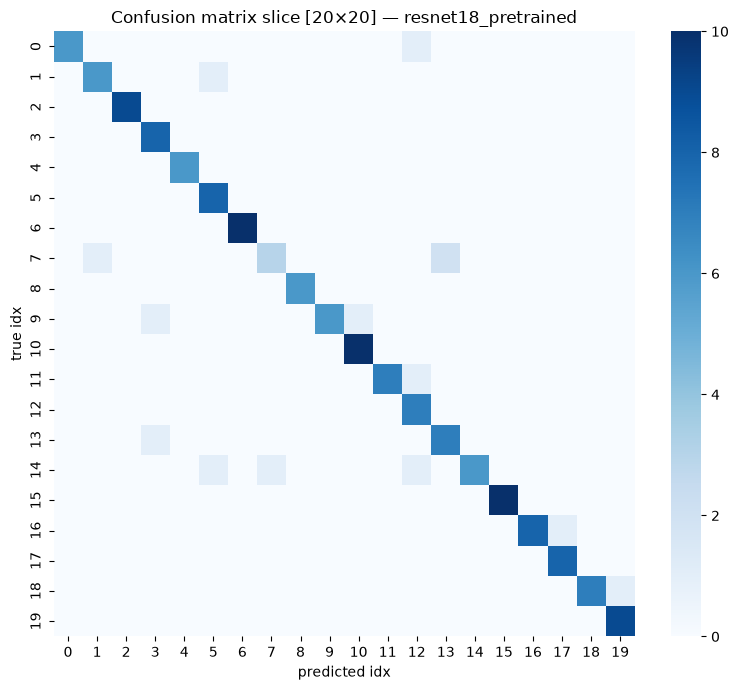

Most confused pairs (true cat_id → pred cat_id, count):
    2277 → 2276    7
    4931 → 4885    5
    1796 → 1799    5
    1569 → 1628    4
    5066 → 4881    4
    7360 → 7343    4
    6323 → 6325    4
    8207 → 8189    4
    3469 → 3458    4
    2787 → 2786    4
      26 → 53      4
    2005 → 2006    4
    1799 → 1796    4
     792 → 443     3
    6577 → 8181    3

Full CM saved to C:\Users\Abdoali\Comp9517\Group_project\Haramcomp9517\dl_pipeline\results\scratch_cm_full.npy


In [8]:
scratch = results[0]
cm = scratch["cm"]

SLICE = 20
cm_slice = cm[:SLICE, :SLICE]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_slice, ax=ax, cmap="Blues", cbar=True)
ax.set_title(f"Confusion matrix slice [{SLICE}×{SLICE}] — {scratch['name']}")
ax.set_xlabel("predicted idx")
ax.set_ylabel("true idx")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "scratch_cm_slice.png", dpi=150)
plt.show()

print("Most confused pairs (true cat_id → pred cat_id, count):")
for true_n, pred_n, cnt in scratch["confused"]:
    print(f"  {true_n:>6} → {pred_n:<6}  {cnt}")

np.save(RESULTS_DIR / "scratch_cm_full.npy", cm)
print(f"\nFull CM saved to {RESULTS_DIR / 'scratch_cm_full.npy'}")